#  Superstore Sales & Profit Analysis
### Author: Owen Nda Diche  
### Tools: Python (pandas, numpy, matplotlib, seaborn)

## Objective
To analyze the Superstore retail dataset and uncover insights related to sales trends, profitability, discount strategy, and product performance.  
This project demonstrates skills in data cleaning, exploratory data analysis (EDA), visualization, and business interpretation.

## Dataset
- Source: Superstore Dataset Final (Vivek468, Kaggle)
- Rows: ~10,000+
- Columns include: Sales, Profit, Region, Category, Sub-Category, Discount, Quantity, State, Order Date, etc.

## Skills Demonstrated
- Data Cleaning & Preprocessing  
- Exploratory Data Analysis (EDA)  
- Creating insightful visualizations  
- Trend analysis  
- Understanding business metrics  
- Deriving actionable insights  
- Storytelling through data  

References:
- Kaggle Superstore Dataset Final: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

## Load the Data & Initial Checks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('superstore_dataset_final.csv', encoding='cp1252')  

# Preview
print(df.head())
print(df.shape)
print(df.info())

# Check for missing values
print(df.isnull().sum())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

##  Data Cleaning
In this section, I inspect the dataset for missing values, incorrect data types, duplicate entries, and general data quality.  
This ensures the analysis is accurate and reliable before moving into deeper insights.


In [27]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check duplicates
dups = df.duplicated().sum()
print("Duplicates:", dups)
df = df.drop_duplicates()

# Check and correct negative or zero quantities (if needed)
print(df['Quantity'].describe())

# Quick stats on numeric columns
print(df[['Sales', 'Profit', 'Discount', 'Quantity']].describe())

Duplicates: 0
count    9994.000000
mean        3.789574
std         2.225110
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: Quantity, dtype: float64
              Sales       Profit     Discount     Quantity
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001    28.656896     0.156203     3.789574
std      623.245101   234.260108     0.206452     2.225110
min        0.444000 -6599.978000     0.000000     1.000000
25%       17.280000     1.728750     0.000000     2.000000
50%       54.490000     8.666500     0.200000     3.000000
75%      209.940000    29.364000     0.200000     5.000000
max    22638.480000  8399.976000     0.800000    14.000000


## Exploratory Data Analysis (EDA)
###  Sales Analysis
Here I explore sales performance across different regions, product categories, and time periods.  
The goal is to identify:
- High and low sales regions  
- Best-selling product categories  
- Monthly/seasonal sales trends  


### Sales & Profit Over Time

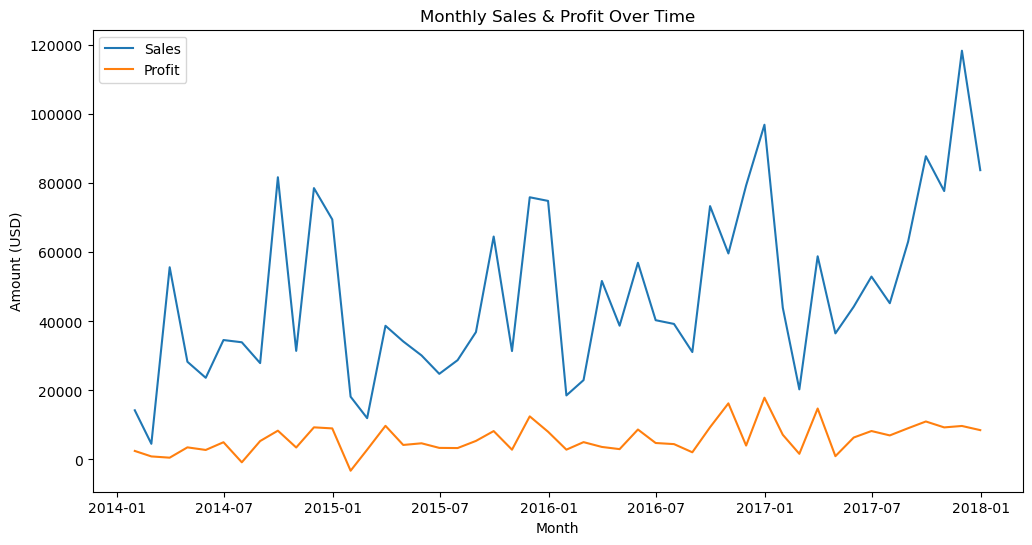

In [28]:
# Aggregate by month
df_month = df.set_index('Order Date').resample('ME').agg({'Sales': 'sum', 'Profit': 'sum'})

plt.figure(figsize=(12,6))
sns.lineplot(data=df_month, x=df_month.index, y='Sales', label='Sales')
sns.lineplot(data=df_month, x=df_month.index, y='Profit', label='Profit')
plt.title('Monthly Sales & Profit Over Time')
plt.xlabel('Month')
plt.ylabel('Amount (USD)')
plt.savefig('sales_vs_profit.png', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()


## Sales & Profit by Region
###  Profit Analysis
This section focuses on profitability across categories and regions.  
It highlights:
- High and low margin products  
- Unprofitable segments  
- How profit varies with customer purchases  


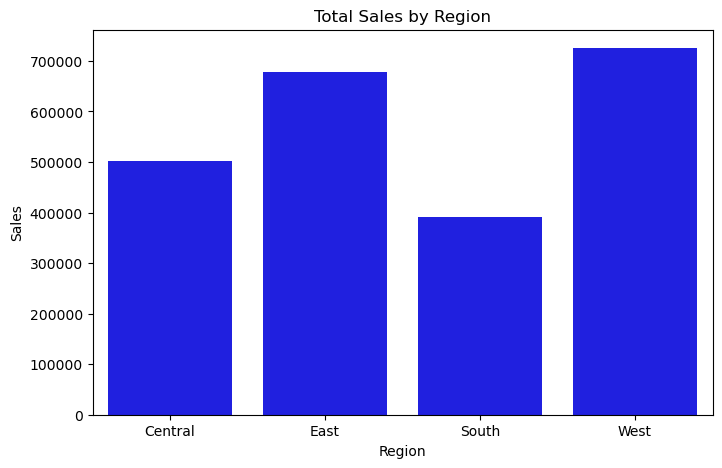

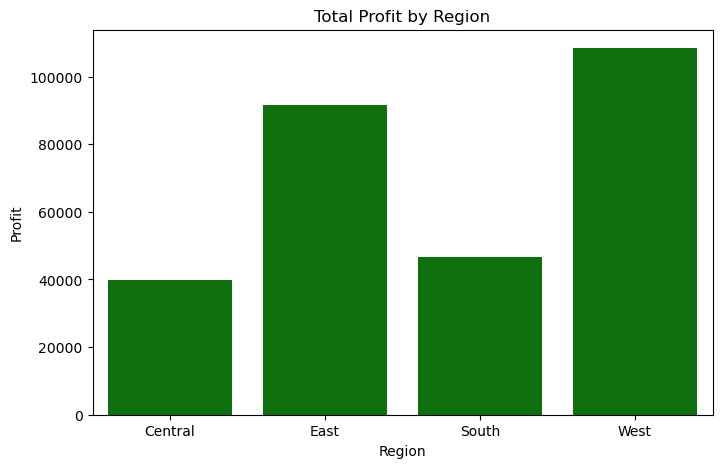

In [29]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_summary, x='Region', y='Sales', color='Blue')
plt.title('Total Sales by Region')
plt.savefig('Total_Sales_by_Region.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=region_summary, x='Region', y='Profit', color='Green')
plt.title('Total Profit by Region')
plt.savefig('Total_Profit_by_Region.png', dpi=300, bbox_inches='tight')
plt.show()


### Sales / Profit by Category and Sub‑Category

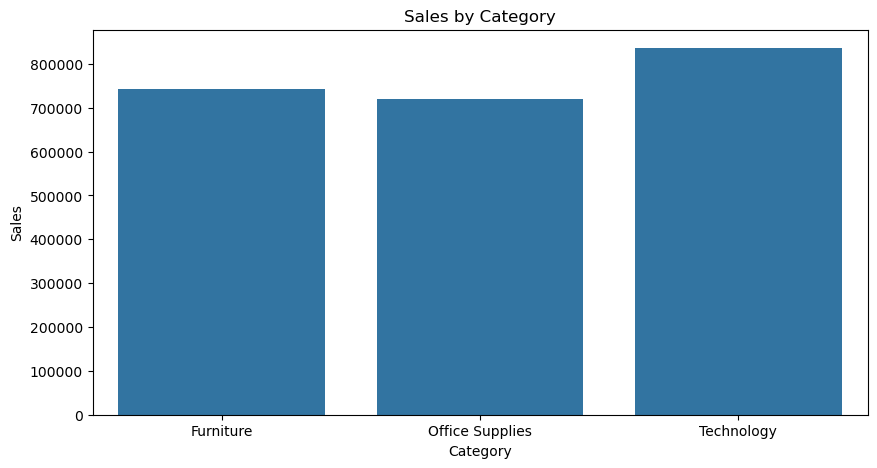

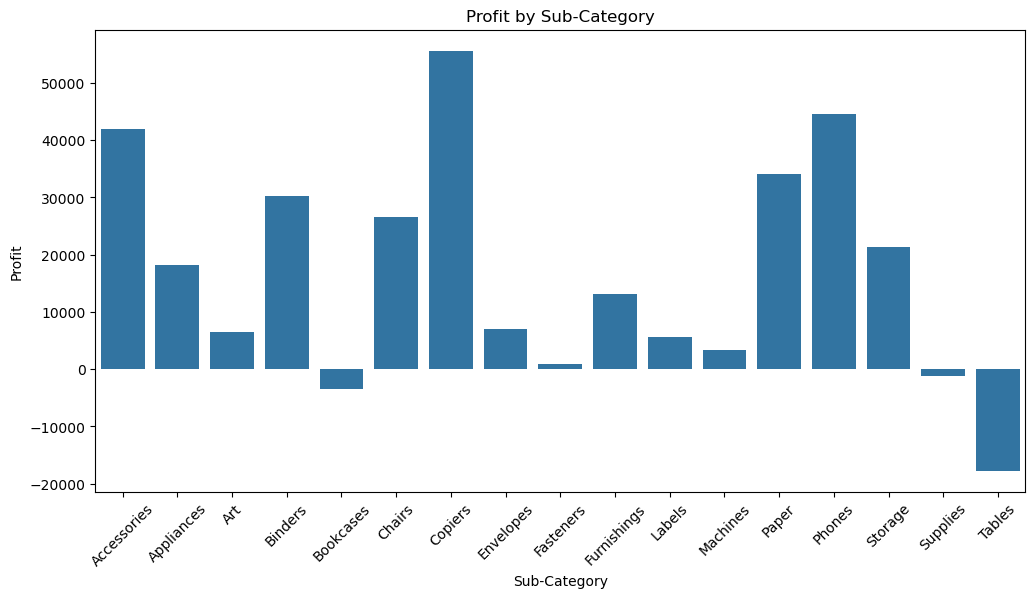

In [30]:
cat_summary = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
subcat_summary = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=cat_summary, x='Category', y='Sales')
plt.title('Sales by Category')
plt.savefig('Sales_by_Category.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(data=subcat_summary, x='Sub-Category', y='Profit')
plt.xticks(rotation=45)
plt.title('Profit by Sub-Category')
plt.savefig('Profit_by_Sub-Category.png', dpi=300, bbox_inches='tight')
plt.show()


##  Discount vs Profit Analysis
In this section, I examine how discounting affects profit.  
This helps determine:
- When discounts help sales  
- When discounts destroy profit  
- Optimal discount ranges  


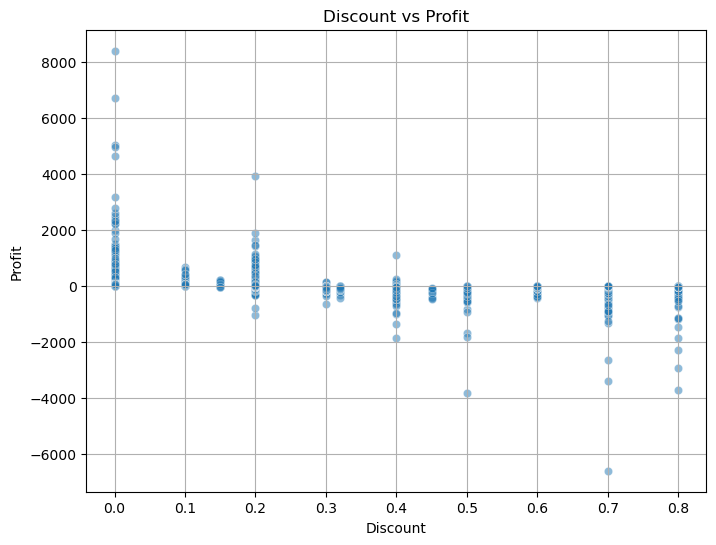

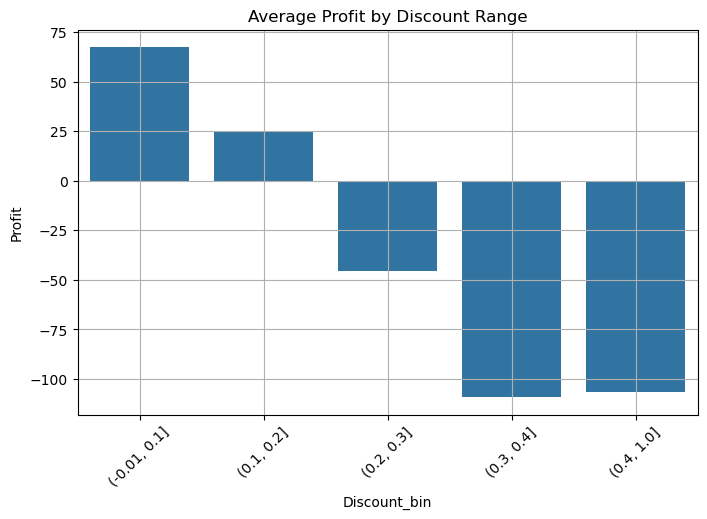

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid()
plt.savefig('Discount_vs_Profit.png', dpi=300, bbox_inches='tight')
plt.show()

# Also consider grouping by discount bins
df['Discount_bin'] = pd.cut(df['Discount'], bins=[-0.01, 0.1, 0.2, 0.3, 0.4, 1.0])
disc_profit = df.groupby('Discount_bin',observed=False)['Profit'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=disc_profit, x='Discount_bin', y='Profit')
plt.xticks(rotation=45)
plt.title('Average Profit by Discount Range')
plt.grid()
plt.savefig('Average_Profit_by_Discount_Range.png', dpi=300, bbox_inches='tight')
plt.show()


### Quantity vs Sales

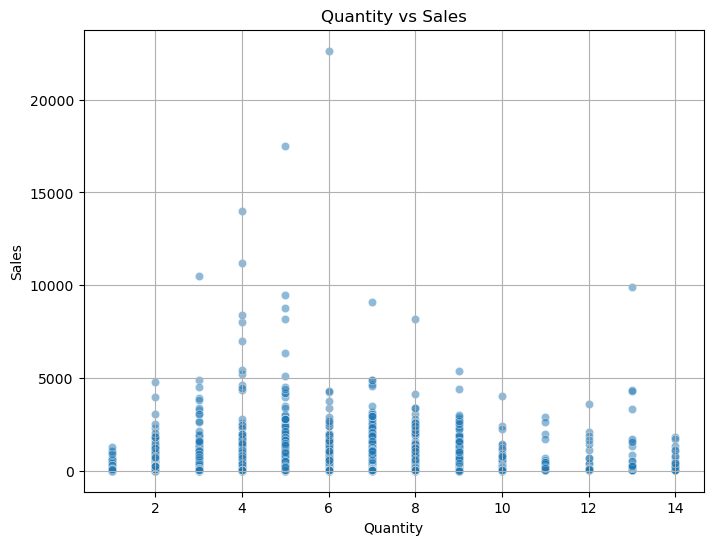

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Quantity', y='Sales', alpha=0.5)
plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.grid()
plt.savefig('Quantity_vs_Sales.png', dpi=300, bbox_inches='tight')
plt.show()

# Final Summary of Insights

##  Sales Trends
- Sales peak toward the end of the year, especially in November and December.
- Technology products are the biggest contributors to revenue.
- Furniture shows steady sales but weak profitability.

##  Profitability Insights
- Tables and Bookcases are major loss-making sub-categories.
- Technology and Office Supplies are high-margin categories.
- Some high-sales regions do not translate into high profit.

##  Discount Strategy Insights
- Discounts above 30% consistently lead to negative profit.
- Moderate discounts (5–15%) boost sales without hurting profit.
- Heavy discounting is the primary reason for losses in the Furniture category.

## Regional Performance
- The West region has the highest sales and profit.
- The South has high sales volume but low profit margins.
- Opportunities exist to improve margins in the Central region.

## Business Recommendations
1. Reduce deep discounting on Furniture — especially Tables.  
2. Increase marketing focus on high-margin Technology products.  
3. Improve pricing strategy in low-profit regions (South & Central).  
4. Prioritize inventory for top-selling categories during Q4.  
5. Investigate operational inefficiencies in loss-making sub-categories.
